In [1]:
import torch
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [6, 3]
from tqdm import tqdm

from data.synthetic_data_sampler import sample_linear_data, sample_semilinear_data
from algos.linear_ts_sampling import ThompsonSampling
from algos.uniform_sampling import UniformSampling
from envs.contextual_bandit import run_contextual_bandit
from utils import sigmoid, softmax, softmax_torch

# Linear reward

The reward score is linear in the context-action feature (as in the original paper):

$$P(y|x,a) = \frac{1}{1 + exp(-w_*^T \cdot [x,a])}$$

Important to note is that a noisy version of this formula implemented, i.e.,
$Y_{observed} = Ber\{p\}$, where $p = \frac{1}{1 + exp(-w_*^T \cdot [x,a] + \varepsilon)}$

In [2]:
from dataclasses import dataclass
@dataclass
class ParamConfig:
    num_actions: int = 3
    context_dim: int = 5
    action_dim: int = 3
    greedy: bool = True
    regularization_strength: float = 1.0
    warmup_batches: int = 5

torch.manual_seed(1234)
k = 20
n = 10000 * 32
d_x = 5
d_a = 3

In [3]:
sampled_vals = sample_linear_data(n, d_x, k, d_a)
dataset, available_actions, (opt_rewards, opt_actions) = sampled_vals

true_scores = dataset[:, d_x + k:]
optimal_actions = true_scores.argmax(axis=1)
normalized_actions_scores = softmax_torch(true_scores).sum(axis=0)

The plot below represents that there single optimal action for a batch of 10000 contexts. This is due to linearity of the underlying reward score with respect to x,a feature. Despite this, the suboptimal gap is quite small and the second best action is relatively close to the best one. 

This is important to note, because a policy observes noisy realization of these scores and suboptimal arms might appear optimal when noise is added.

Note: the scale of the normalized scores (orange) doesn't matter here.

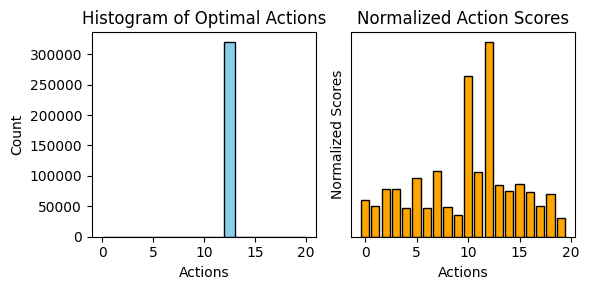

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].hist(optimal_actions, bins=range(0, k + 1), color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Optimal Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')

axes[1].bar(range(k), normalized_actions_scores, color='orange', edgecolor='black')
axes[1].set_title('Normalized Action Scores')
axes[1].set_xlabel('Actions')
axes[1].set_ylabel('Normalized Scores')
axes[1].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()

In [5]:
hparams = {
        'context_dim': d_x,
        'action_dim': d_a,
        'num_actions': len(available_actions),
    }
hparams = ParamConfig(**hparams)
random = UniformSampling('random', hparams)

batch_size = 32

h_actions, h_rewards, h_regrets = run_contextual_bandit(
    d_x, available_actions, dataset, 
    [random], batch_size, verbose=True
)
h_actions, h_rewards, h_regrets = h_actions.reshape(-1), h_rewards.reshape(-1), h_regrets.reshape(-1)

optimal_actions_hist = [optimal_actions.tolist().count(val) for val in range(k)]
random_chosen_actions = h_actions.tolist()
random_chosen_actions_hist = [random_chosen_actions.count(val) for val in range(k)]
random_regret = h_regrets.view(-1, batch_size).mean(1)

      0/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      1/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      2/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      3/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      4/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      5/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      6/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      7/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      8/  10000 - loss: N/A, mse scores: N/A, variance: N/A
      9/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     10/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     11/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     12/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     13/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     14/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     15/  10000 - loss: N/A, mse scores: N/A, variance: N/A
     16/  10000 - loss: N/A, mse scores:

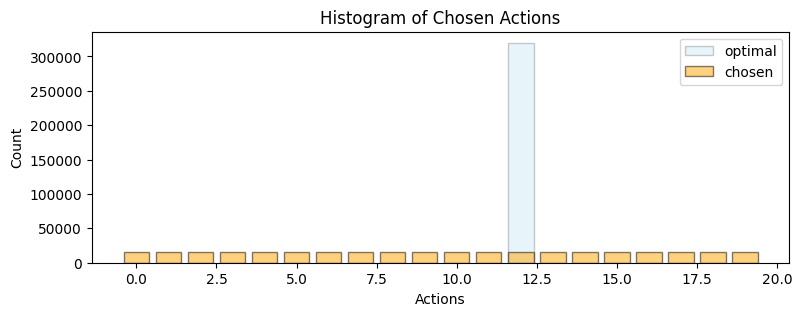

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(9, 3), sharey=False)
axes.bar(range(k), optimal_actions_hist, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes.bar(range(k), random_chosen_actions_hist, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes.set_title('Histogram of Chosen Actions')
axes.set_xlabel('Actions')
axes.set_ylabel('Count')
axes.legend()

## Run single experiment 

Running an experiment for Thompson sampling policy, we track 3 values:
- Mean squared error between learned params $\hat{w}$ and true params $w_*$
- Mean squared error between learned scores $\hat{p}$ and true scores $p_*$
- variance $q$ of the posterior distribution

In [7]:
hparams_ts_linear = {
        'context_dim': d_x,
        'action_dim': d_a,
        'num_actions': len(available_actions),
        'greedy': False,
        'regularization_strength': .1,
        'warmup_batches': 0
    }
hparams_ts_linear = ParamConfig(**hparams_ts_linear)
policy = ThompsonSampling('Thompson linear', hparams_ts_linear)

batch_size = 32

h_actions, h_rewards, h_regrets = run_contextual_bandit(
    d_x, available_actions, dataset, 
    [policy], batch_size, verbose=True
)

ts_chosen_actions = h_actions.reshape(-1).tolist()
ts_chosen_actions_hist = [ts_chosen_actions.count(val) for val in range(k)]
ts_regret = h_regrets.view(-1, batch_size).mean(1)

      0/  10000 - loss: N/A, mse scores: 29.4508, variance: 2.1145
      1/  10000 - loss: N/A, mse scores: 22.9123, variance: 1.5360
      2/  10000 - loss: N/A, mse scores: 7.3542, variance: 1.1993
      3/  10000 - loss: N/A, mse scores: 7.3503, variance: 0.8977
      4/  10000 - loss: N/A, mse scores: 4.6573, variance: 0.7205
      5/  10000 - loss: N/A, mse scores: 6.4413, variance: 0.5814
      6/  10000 - loss: N/A, mse scores: 2.8527, variance: 0.4736
      7/  10000 - loss: N/A, mse scores: 5.0515, variance: 0.4090
      8/  10000 - loss: N/A, mse scores: 4.1148, variance: 0.3659
      9/  10000 - loss: N/A, mse scores: 2.5993, variance: 0.3231
     10/  10000 - loss: N/A, mse scores: 2.5309, variance: 0.2992
     11/  10000 - loss: N/A, mse scores: 2.0991, variance: 0.2780
     12/  10000 - loss: N/A, mse scores: 3.5275, variance: 0.2642
     13/  10000 - loss: N/A, mse scores: 0.8251, variance: 0.2430
     14/  10000 - loss: N/A, mse scores: 1.3156, variance: 0.2244
     15/

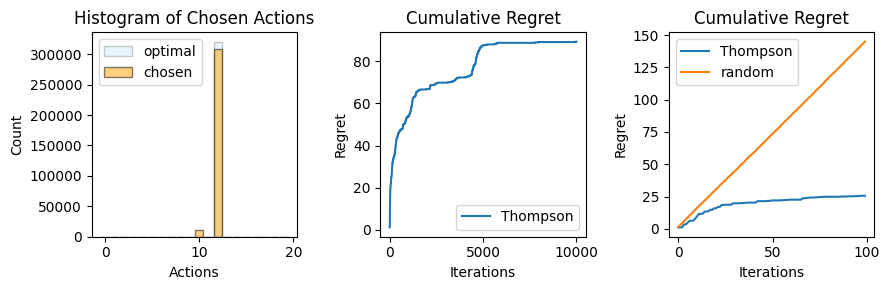

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)
axes[0].bar(range(k), optimal_actions_hist, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), ts_chosen_actions_hist, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(ts_regret.cumsum(dim=0), label='Thompson')
#axes[1].plot(random_regret.cumsum(dim=0), label='random')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

# the same plot, but with random performance
axes[2].plot(ts_regret.cumsum(dim=0)[:100], label='Thompson')
axes[2].plot(random_regret.cumsum(dim=0)[:100], label='random')
axes[2].set_title('Cumulative Regret')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Regret')
axes[2].legend()

plt.tight_layout()
plt.show()

In [9]:
batch_size = 32

algos = []
for j, reg_strength in enumerate([0.1, 1., 10.]):
    hparams_ts_linear = {
            'context_dim': d_x,
            'action_dim': d_a,
            'num_actions': len(available_actions),
            'greedy': False,
            'warmup_batches': 0
        }
    hparams_ts_linear['regularization_strength'] = reg_strength
    hparams_ts_linear = ParamConfig(**hparams_ts_linear)
    policy = ThompsonSampling('Thompson linear_' + str(reg_strength), hparams_ts_linear)
    algos.append(policy)

h_actions, h_rewards, h_regrets = run_contextual_bandit(
    d_x, available_actions, dataset, 
    algos, batch_size, verbose=False
)

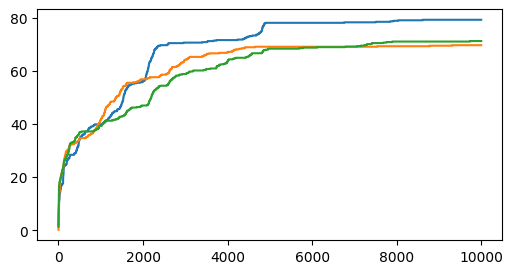

In [10]:
plt.plot(h_regrets.view(-1, batch_size, len(algos)).mean(1).cumsum(0))

# Nonlinear reward

To ensure the optimal action varies with context features, we integrate the context features $x$ with the action features $a$. Instead of fixed features $a$, define $a(x)$ so that action features dynamically interact with $x$: $a(x) = a + L(a) \cdot x$, where $L$ is the context-action weight vector.

So, in this setting, the reward score is linear in the $x, a(x)$ features:

$$P(y|x,a) = \frac{1}{1 + exp(-w_*^T \cdot [x, a(x)])}.$$

Such a reward structure represents a set of linear functions for a given $a$, but the overall reward structure, across different actions $a$, is nonlinear. Intuitively, Regularized Logistic regression should have trouble learning such rewards because weights $L(a)$ are never presented explicitly, and the parameterization of the policy shouldn't be able to capture these dependencies.

In [11]:
sampled_vals = sample_semilinear_data(n, d_x, k, d_a)
dataset, available_actions, (opt_rewards, opt_actions) = sampled_vals

true_scores = dataset[:, d_x + k:]
optimal_actions = true_scores.argmax(axis=1)
normalized_actions_scores = softmax_torch(true_scores).sum(axis=0)

In the plot below, normalized scores (orange) show that over the whole population, there is an optimal action - action 16; nevertheless, optimal actions (blue) show that optimality given context $x$ varies.

Note: the scale of the normalized scores (orange) doesn't matter here.

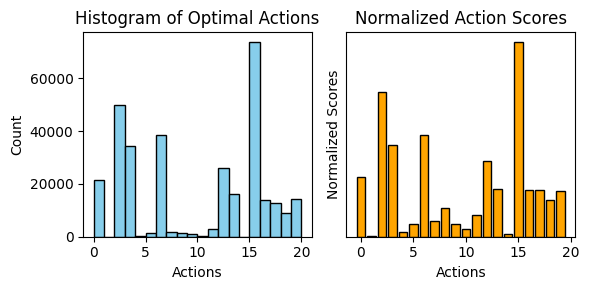

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].hist(optimal_actions, bins=range(0, k + 1), color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Optimal Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')

axes[1].bar(range(k), normalized_actions_scores, color='orange', edgecolor='black')
axes[1].set_title('Normalized Action Scores')
axes[1].set_xlabel('Actions')
axes[1].set_ylabel('Normalized Scores')
axes[1].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()

## Run single experiment

Run random model again

In [13]:
hparams = {
        'context_dim': d_x,
        'action_dim': d_a,
        'num_actions': len(available_actions),
    }
hparams = ParamConfig(**hparams)
random = UniformSampling('random', hparams)

batch_size = 32

h_actions, h_rewards, h_regrets = run_contextual_bandit(
    d_x, available_actions, dataset, 
    [random], batch_size, verbose=False
)
h_actions, h_rewards, h_regrets = h_actions.reshape(-1), h_rewards.reshape(-1), h_regrets.reshape(-1)

optimal_actions_hist = [optimal_actions.tolist().count(val) for val in range(k)]
random_chosen_actions = h_actions.tolist()
random_chosen_actions_hist = [random_chosen_actions.count(val) for val in range(k)]
random_regret = h_regrets.view(-1, batch_size).mean(1)

Run thompson sampling for nonlinear data in verbose mode

In [14]:
hparams_ts_linear = {
        'context_dim': d_x,
        'action_dim': d_a,
        'num_actions': len(available_actions),
        'greedy': False,
        'regularization_strength': .1,
        'warmup_batches': 0
    }
hparams_ts_linear = ParamConfig(**hparams_ts_linear)
policy = ThompsonSampling('Thompson linear', hparams_ts_linear)

batch_size = 32

h_actions, h_rewards, h_regrets = run_contextual_bandit(
    d_x, available_actions, dataset, 
    [policy], batch_size, verbose=True
)

ts_chosen_actions = h_actions.reshape(-1).tolist()
ts_chosen_actions_hist = [ts_chosen_actions.count(val) for val in range(k)]
ts_regret = h_regrets.view(-1, batch_size).mean(1)

      0/  10000 - loss: N/A, mse scores: 114.2594, variance: 6.1277
      1/  10000 - loss: N/A, mse scores: 73.7003, variance: 4.3119
      2/  10000 - loss: N/A, mse scores: 166.5199, variance: 2.2624
      3/  10000 - loss: N/A, mse scores: 23.7631, variance: 1.5038
      4/  10000 - loss: N/A, mse scores: 37.5795, variance: 1.2119
      5/  10000 - loss: N/A, mse scores: 22.4020, variance: 1.0356
      6/  10000 - loss: N/A, mse scores: 41.9905, variance: 0.7953
      7/  10000 - loss: N/A, mse scores: 23.7849, variance: 0.7412
      8/  10000 - loss: N/A, mse scores: 34.4020, variance: 0.6708
      9/  10000 - loss: N/A, mse scores: 30.5372, variance: 0.6431
     10/  10000 - loss: N/A, mse scores: 39.9218, variance: 0.6139
     11/  10000 - loss: N/A, mse scores: 22.0693, variance: 0.5636
     12/  10000 - loss: N/A, mse scores: 33.1240, variance: 0.5403
     13/  10000 - loss: N/A, mse scores: 32.6951, variance: 0.5150
     14/  10000 - loss: N/A, mse scores: 74.0112, variance: 

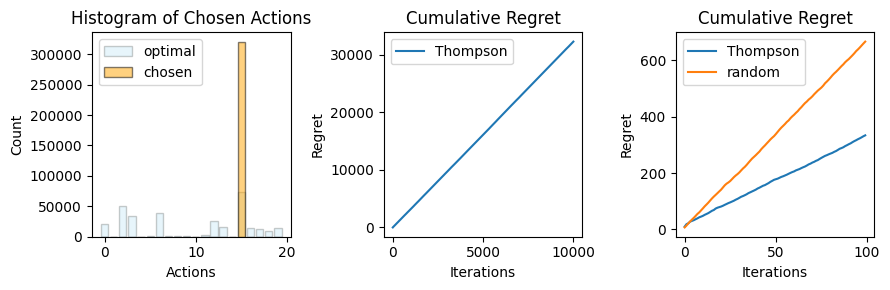

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)
axes[0].bar(range(k), optimal_actions_hist, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), ts_chosen_actions_hist, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(ts_regret.cumsum(dim=0), label='Thompson')
#axes[1].plot(random_regret.cumsum(dim=0), label='random')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

# the same plot, but with random performance
axes[2].plot(ts_regret.cumsum(dim=0)[:100], label='Thompson')
axes[2].plot(random_regret.cumsum(dim=0)[:100], label='random')
axes[2].set_title('Cumulative Regret')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Regret')
axes[2].legend()

plt.tight_layout()
plt.show()

In the case of nonlinear reward, Thompson sampling learned the best average action and struggled to adapt to different contexts. This is expected because the learned parameters $\hat{w}$ are inherently less expressive than the parameter of the true data-generating process $w_*$ and $L$.